# DSA 4060 Recommender Systems — Week 1 Practical
## Build and Publish a Popularity-Based Movie Recommender

- **Course:** DSA 4060 Recommender Systems
- **Student name:** Your Name
- **Student number:** Your Number
- **Date:** 21 September 2026
- **Purpose:** Load and validate the MovieLens *latest-small* ratings, explore the user–item interactions, and build two transparent, non-personalized recommendation baselines (a minimum-ratings popularity list and a weighted-rating list). The results are tested, interpreted, and published as a reproducible GitHub project that later personalized models can be compared against.

## Part 1 — Understand the recommendation problem

**Core concepts (as used in this notebook)**

| Concept | Meaning here |
|---|---|
| User | A person identified by `userId` who rates movies. |
| Item | A movie identified by `movieId`. |
| Interaction | One rating a user gave to one movie (one row of `ratings.csv`). |
| Explicit feedback | A preference the user states directly: a star rating from 0.5 to 5.0. |
| Recommendation | A ranked list of items chosen for a user or for an audience. |
| Baseline | A simple reference method that more advanced models must beat. |

**Business scenario.** A new streaming service knows too little about each visitor to personalize its home page, so it needs a dependable list of widely liked movies. A film must not top the list because a single person gave it five stars; the method has to weigh *how well* a movie is rated (average rating) together with *how much evidence* exists (number of ratings).

**Questions this notebook answers**

- Which movies have received the most ratings?
- Which movies have the highest average ratings?
- Why can average rating alone be misleading?
- How can rating volume and rating quality be combined?
- What limitations does one shared Top 10 list have?

**Data flow.** `ratings.csv` supplies the user–item interactions and `movies.csv` supplies titles and genres. The notebook validates both files, summarizes the ratings, aggregates them by movie, joins the titles, ranks the candidates, and displays the recommendations.

## Part 2 — Project setup

The notebook lives in `notebooks/`, so `..` points to the project root and every path below is relative (no machine-specific paths).

**Dataset:** MovieLens *latest-small* from GroupLens (<https://grouplens.org/datasets/movielens/>), files `movies.csv` and `ratings.csv`, unmodified. The dataset README and licence text are kept in `data/ml-latest-small-README.txt`.

## Part 3 — Load and inspect the data

### 3.1 Import libraries

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

### 3.2 Define file paths

In [2]:
PROJECT_ROOT = Path('..')
DATA_DIR = PROJECT_ROOT / 'data'
IMAGES_DIR = PROJECT_ROOT / 'images'
IMAGES_DIR.mkdir(exist_ok=True)

MOVIES_FILE = DATA_DIR / 'movies.csv'
RATINGS_FILE = DATA_DIR / 'ratings.csv'

# Fail early with an actionable message if the data files are missing.
for required_file in (MOVIES_FILE, RATINGS_FILE):
    if not required_file.exists():
        raise FileNotFoundError(
            f'{required_file} not found. Download MovieLens latest-small from '
            'https://grouplens.org/datasets/movielens/ and copy movies.csv and '
            'ratings.csv into the data/ folder.'
        )

### 3.3 Load the CSV files

In [3]:
movies = pd.read_csv(MOVIES_FILE)
ratings = pd.read_csv(RATINGS_FILE)

print('Movies shape:', movies.shape)
print('Ratings shape:', ratings.shape)

Movies shape: (9742, 3)
Ratings shape: (100836, 4)


The catalogue file has **9,742 movies** with 3 columns, and the ratings file has **100,836 ratings** with 4 columns. These are the counts of the downloaded version of the dataset (GroupLens may update the file, so counts should always be recorded from the version actually used).

### 3.4 Preview and inspect

In [4]:
display(movies.head())
display(ratings.head())
print(movies.info())
print(ratings.info())

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 228.5 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None


`movies` has the expected columns `movieId`, `title`, `genres` (genres are pipe-separated strings such as `Adventure|Children`). `ratings` has `userId`, `movieId`, `rating`, `timestamp` (Unix seconds). Identifiers and timestamps are integers, ratings are floats, and every column reports the full row count as non-null.

### 3.5 Validate the data

In [5]:
print('Missing values in movies:')
print(movies.isna().sum())
print('Missing values in ratings:')
print(ratings.isna().sum())
print('Duplicate movie rows:', movies.duplicated().sum())
print('Duplicate rating rows:', ratings.duplicated().sum())
print('Rating range:', ratings['rating'].min(), 'to', ratings['rating'].max())
print('Unknown movie IDs:', (~ratings['movieId'].isin(movies['movieId'])).sum())

Missing values in movies:
movieId    0
title      0
genres     0
dtype: int64
Missing values in ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
Duplicate movie rows: 0
Duplicate rating rows: 0
Rating range: 0.5 to 5.0
Unknown movie IDs: 0


The practical asks us to decide which fields identify a record before treating a duplicate count as a problem. The identity checks below use those keys directly.

In [6]:
print('Repeated (userId, movieId) pairs in ratings:', ratings.duplicated(['userId', 'movieId']).sum())
print('Repeated movieId values in movies:', movies['movieId'].duplicated().sum())
print('Titles that appear more than once:', movies['title'].duplicated().sum())
display(movies[movies['title'].duplicated(keep=False)].sort_values('title'))

Repeated (userId, movieId) pairs in ratings: 0
Repeated movieId values in movies: 0
Titles that appear more than once: 5


,movieId,title,genres
4169,6003,Confessions of a Dangerous Mind (2002),Comedy|Crime|Drama|Thriller
9106,144606,Confessions of a Dangerous Mind (2002),Comedy|Crime|Drama|Romance|Thriller
650,838,Emma (1996),Comedy|Drama|Romance
5601,26958,Emma (1996),Romance
5854,32600,Eros (2004),Drama
9135,147002,Eros (2004),Drama|Romance
2141,2851,Saturn 3 (1980),Adventure|Sci-Fi|Thriller
9468,168358,Saturn 3 (1980),Sci-Fi|Thriller
5931,34048,War of the Worlds (2005),Action|Adventure|Sci-Fi|Thriller
6932,64997,War of the Worlds (2005),Action|Sci-Fi


**Interpretation.** There are no missing values in either file, no fully duplicated rows, and every rating refers to a movie that exists in `movies.csv` (0 unknown IDs). Ratings lie between 0.5 and 5.0, which matches the documented half-star scale. A rating is uniquely identified by the pair (`userId`, `movieId`), and no pair repeats, so each user rated each movie at most once and no rows need to be removed. `movieId` is unique in `movies.csv`. Five *titles* occur twice, but under different `movieId` values and with different genre lists (for example two records for *Emma (1996)*), so they are distinct catalogue entries rather than duplicated rows; the recommender therefore keys on `movieId`, never on `title`. Nothing is dropped or altered.

### 3.6 Summarize the interaction data

In [7]:
n_users = ratings['userId'].nunique()
n_movies_rated = ratings['movieId'].nunique()
n_interactions = len(ratings)

print('Unique users:', n_users)
print('Movies with at least one rating:', n_movies_rated)
print('Total rating interactions:', n_interactions)
print(ratings['rating'].describe())

Unique users: 610
Movies with at least one rating: 9724
Total rating interactions: 100836
count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64


- **Unique users (610):** the number of distinct people who contributed at least one rating.
- **Movies with at least one rating (9,724):** the items that carry any preference information. This is *not* the number of movies in `movies.csv` (9,742); the 18 catalogue entries with no ratings can never be ranked by a rating-based method.
- **Total rating interactions (100,836):** the number of user–movie ratings, i.e. the observed cells of the user–item matrix.
- **Rating summary:** the mean is about 3.50 and the median 3.5 (standard deviation about 1.04), on a scale that runs from 0.5 to 5.0.

## Part 4 — Explore user–item interactions

### 4.1 Ratings per user and per movie

In [8]:
ratings_per_user = ratings.groupby('userId').size()
ratings_per_movie = ratings.groupby('movieId').size()

print('Ratings per user:')
print(ratings_per_user.describe())
print()
print('Ratings per movie:')
print(ratings_per_movie.describe())

Ratings per user:
count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
dtype: float64

Ratings per movie:
count    9724.000000
mean       10.369807
std        22.401005
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
dtype: float64


Both distributions are strongly right-skewed. Every user rated at least 20 movies (the dataset was built that way), but the median user rated about 70 while one user rated 2,698. For movies the imbalance is sharper: the median movie has only **3** ratings, the mean is about 10.4, and the most-rated movie has 329. So a small number of very active users and very popular movies carry most of the data, while most movies have thin evidence.

In [9]:
print('Movies with exactly 1 rating:', (ratings_per_movie == 1).sum())
print('Movies with at least 50 ratings:', (ratings_per_movie >= 50).sum())
print('Share of rated movies with at least 50 ratings: {:.1%}'.format((ratings_per_movie >= 50).mean()))

Movies with exactly 1 rating: 3446
Movies with at least 50 ratings: 450
Share of rated movies with at least 50 ratings: 4.6%


3,446 movies (about 35% of the rated movies) have a single rating, while only 450 (about 4.6%) have 50 or more. This is the reason a raw average is unreliable for most of the catalogue, and it sets up the thresholds in Parts 5 and 6.

### 4.2 Examine the rating distribution

rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64


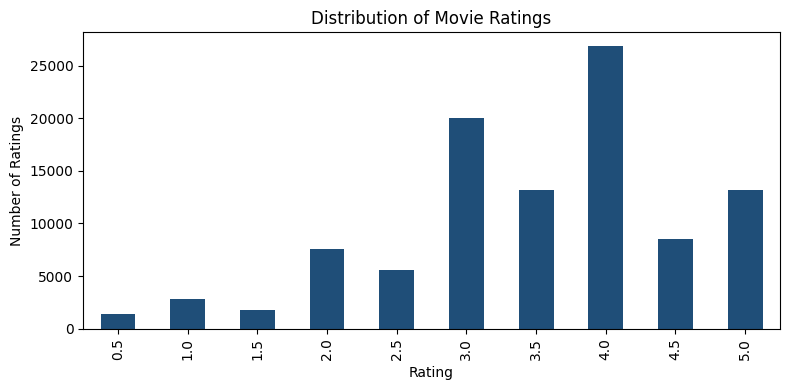

In [10]:
rating_distribution = ratings['rating'].value_counts().sort_index()
print(rating_distribution)

ax = rating_distribution.plot(kind='bar', color='#1F4E78', figsize=(8, 4))
ax.set_title('Distribution of Movie Ratings')
ax.set_xlabel('Rating')
ax.set_ylabel('Number of Ratings')
plt.tight_layout()
plt.show()

**Interpretation.** The most frequent rating is **4.0** (26,818 ratings), followed by 3.0 (20,047), then 5.0 (13,211). Low ratings are comparatively uncommon: ratings of 2.0 or below make up about 13% of all ratings, whereas ratings of 4.0 or above make up about 48%. Whole-star values are used more often than the half-star values next to them. The chart shows *what* was rated, not *why*; it does not tell us whether users prefer to rate movies they like or whether the movies are simply good.

### 4.3 Calculate interaction-matrix sparsity

In [11]:
possible_interactions = n_users * n_movies_rated
observed_interactions = n_interactions
sparsity = 1 - (observed_interactions / possible_interactions)

print(f'Possible interactions: {possible_interactions:,}')
print(f'Observed interactions: {observed_interactions:,}')
print(f'Sparsity: {sparsity:.2%}')

Possible interactions: 5,931,640
Observed interactions: 100,836
Sparsity: 98.30%


**Interpretation.** A full user–movie matrix would have 610 × 9,724 = 5,931,640 cells, but only 100,836 hold a rating, so **98.30%** of the cells are empty (only about 1.70% are observed). Users see and rate a tiny fraction of the catalogue. Personalized methods must therefore predict preferences from very limited observations. The popularity baselines in this notebook sidestep that problem by ignoring the empty cells altogether: they never try to predict what a specific user would rate an unseen movie.

## Part 5 — Build a popularity recommender

### 5.1 Aggregate ratings by movie

In [12]:
movie_stats = (
    ratings.groupby('movieId')
    .agg(average_rating=('rating', 'mean'),
         rating_count=('rating', 'count'))
    .reset_index()
)

movie_stats = movie_stats.merge(
    movies[['movieId', 'title', 'genres']],
    on='movieId',
    how='left',
    validate='one_to_one'
)

display(movie_stats.head())

,movieId,average_rating,rating_count,title,genres
0,1,3.920930,215,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,3.431818,110,Jumanji (1995),Adventure|Children|Fantasy
2,3,3.259615,52,Grumpier Old Men (1995),Comedy|Romance
3,4,2.357143,7,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,3.071429,49,Father of the Bride Part II (1995),Comedy


Each row is now one movie with its average rating, its rating count, and a readable title and genre list. `validate='one_to_one'` would raise an error if either side contained repeated `movieId` values, which protects against silently multiplying rows; the merge succeeded, confirming the IDs are unique on both sides.

### 5.2 Most-rated movies

In [13]:
most_rated = (
    movie_stats.sort_values(
        ['rating_count', 'average_rating'],
        ascending=[False, False]
    )
    .head(10)
)

display(most_rated[['title', 'rating_count', 'average_rating']])

,title,rating_count,average_rating
314,Forrest Gump (1994),329,4.164134
277,"Shawshank Redemption, The (1994)",317,4.429022
257,Pulp Fiction (1994),307,4.197068
510,"Silence of the Lambs, The (1991)",279,4.161290
1938,"Matrix, The (1999)",278,4.192446
224,Star Wars: Episode IV - A New Hope (1977),251,4.231076
418,Jurassic Park (1993),238,3.750000
97,Braveheart (1995),237,4.031646
507,Terminator 2: Judgment Day (1991),224,3.970982
461,Schindler's List (1993),220,4.225000


This list measures visibility or engagement. *Forrest Gump (1994)* is the most rated movie (329 ratings, average about 4.16), followed by *The Shawshank Redemption* (317) and *Pulp Fiction* (307). Rating volume is not quality: *Jurassic Park (1993)* is among the most-rated titles but its average (3.75) is clearly lower than the others in the list.

### 5.3 Highest average ratings

In [14]:
highest_average = (
    movie_stats.sort_values(
        ['average_rating', 'rating_count'],
        ascending=[False, False]
    )
    .head(10)
)

display(highest_average[['title', 'rating_count', 'average_rating']])

,title,rating_count,average_rating
48,Lamerica (1994),2,5.0
87,Heidi Fleiss: Hollywood Madam (1995),2,5.0
869,Lesson Faust (1994),2,5.0
2593,Jonah Who Will Be 25 in the Year 2000 (Jonas q...,2,5.0
4384,Belle époque (1992),2,5.0
4583,Come and See (Idi i smotri) (1985),2,5.0
7347,Enter the Void (2009),2,5.0
121,"Awfully Big Adventure, An (1995)",1,5.0
405,Live Nude Girls (1995),1,5.0
432,In the Realm of the Senses (Ai no corrida) (1976),1,5.0


Every movie in this list has an average of exactly 5.0, and every one of them has only **one or two** ratings. Ranking by average alone therefore rewards tiny samples: one or two enthusiastic users are enough to top the list. This is why average rating alone is a weak popularity baseline.

### 5.4 Minimum-ratings baseline

A movie must have at least 50 ratings before it is ranked by average rating. The threshold of 50 is a teaching choice, not a universal rule.

In [15]:
MIN_RATINGS = 50

popular_movies = (
    movie_stats[movie_stats['rating_count'] >= MIN_RATINGS]
    .sort_values(
        ['average_rating', 'rating_count'],
        ascending=[False, False]
    )
    .head(10)
)

display(popular_movies[['title', 'genres', 'rating_count', 'average_rating']])
print('Movies eligible under the threshold:', (movie_stats['rating_count'] >= MIN_RATINGS).sum())

,title,genres,rating_count,average_rating
277,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
659,"Godfather, The (1972)",Crime|Drama,192,4.289062
2224,Fight Club (1999),Action|Crime|Drama|Thriller,218,4.272936
974,Cool Hand Luke (1967),Drama,57,4.271930
602,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,97,4.268041
686,Rear Window (1954),Mystery|Thriller,84,4.261905
921,"Godfather: Part II, The (1974)",Crime|Drama,129,4.259690
6298,"Departed, The (2006)",Crime|Drama|Thriller,107,4.252336
913,Goodfellas (1990),Crime|Drama,126,4.250000
694,Casablanca (1942),Drama|Romance,100,4.240000


Movies eligible under the threshold: 450


With the threshold, the list is filled with well-known, well-rated titles: *The Shawshank Redemption* is first (average about 4.43 from 317 ratings), followed by *The Godfather* and *Fight Club*. All 10 movies have at least 57 ratings. Only **450** movies pass the threshold, so the cutoff removes about 95% of the rated catalogue from consideration.

### 5.5 Convert the logic into a function

In [16]:
def recommend_popular_movies(stats, min_ratings=50, top_n=10):
    candidates = stats[stats['rating_count'] >= min_ratings].copy()
    return (
        candidates.sort_values(
            ['average_rating', 'rating_count'],
            ascending=[False, False]
        )
        .head(top_n)
        [['movieId', 'title', 'genres', 'rating_count', 'average_rating']]
    )


recommendations = recommend_popular_movies(movie_stats, 50, 10)
display(recommendations)

,movieId,title,genres,rating_count,average_rating
277,318,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
659,858,"Godfather, The (1972)",Crime|Drama,192,4.289062
2224,2959,Fight Club (1999),Action|Crime|Drama|Thriller,218,4.272936
974,1276,Cool Hand Luke (1967),Drama,57,4.271930
602,750,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,97,4.268041
686,904,Rear Window (1954),Mystery|Thriller,84,4.261905
921,1221,"Godfather: Part II, The (1974)",Crime|Drama,129,4.259690
6298,48516,"Departed, The (2006)",Crime|Drama|Thriller,107,4.252336
913,1213,Goodfellas (1990),Crime|Drama,126,4.250000
694,912,Casablanca (1942),Drama|Romance,100,4.240000


The function packages the logic so the threshold and list length become parameters and the same rule can be reused on other subsets (a genre, a period). It keeps `movieId` in the output so results can be joined back to other data.

## Part 6 — Build a weighted-rating baseline

### 6.1 Why a weighted score

A hard threshold discards every movie below the cutoff, however good it might be. A **weighted rating** instead pulls the estimate for a movie with few ratings toward the overall mean and lets movies with many ratings speak for themselves:

$$\text{weighted score} = \frac{v}{v+m}\,R + \frac{m}{v+m}\,C$$

where $R$ is the movie's average rating, $v$ its number of ratings, $C$ the overall mean rating, and $m$ the minimum-evidence threshold.

### 6.2 Select the threshold

In [17]:
C = ratings['rating'].mean()
m = movie_stats['rating_count'].quantile(0.90)

print(f'Overall mean rating C: {C:.3f}')
print(f'90th percentile rating count m: {m:.1f}')

Overall mean rating C: 3.502
90th percentile rating count m: 27.0


The overall mean rating is **C = 3.502** and the 90th-percentile rating count is **m = 27**. Using the 90th percentile means only movies in roughly the top 10% by rating count qualify (976 movies, see below). It is an explicit and transparent policy choice, and it is tested with other percentiles in section 6.5.

### 6.3 Calculate weighted scores

In [18]:
qualified = movie_stats[movie_stats['rating_count'] >= m].copy()

v = qualified['rating_count']
R = qualified['average_rating']

qualified['weighted_score'] = (
    (v / (v + m)) * R +
    (m / (v + m)) * C
)

weighted_recommendations = (
    qualified.sort_values(
        ['weighted_score', 'rating_count'],
        ascending=[False, False]
    )
    .head(10)
)

print('Movies qualified under the 90th-percentile threshold:', len(qualified))
display(weighted_recommendations[[
    'title', 'genres', 'rating_count',
    'average_rating', 'weighted_score'
]])

Movies qualified under the 90th-percentile threshold: 976


,title,genres,rating_count,average_rating,weighted_score
277,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022,4.356227
659,"Godfather, The (1972)",Crime|Drama,192,4.289062,4.191973
2224,Fight Club (1999),Action|Crime|Drama|Thriller,218,4.272936,4.187927
224,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,251,4.231076,4.160223
46,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,204,4.237745,4.151697
461,Schindler's List (1993),Drama|War,220,4.225000,4.145919
257,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,307,4.197068,4.140844
897,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi,211,4.215640,4.134630
1938,"Matrix, The (1999)",Action|Sci-Fi|Thriller,278,4.192446,4.131285
921,"Godfather: Part II, The (1974)",Crime|Drama,129,4.259690,4.128475


**976** movies qualify. *The Shawshank Redemption* is again first (weighted score about 4.36). Each weighted score sits between the movie's own average and the global mean of 3.50, and the shift is larger for movies with fewer ratings: for example *The Godfather: Part II* (129 ratings) drops from an average of about 4.26 to a weighted score of about 4.13, while *The Shawshank Redemption* (317 ratings) only drops from 4.43 to 4.36. Every movie in this Top 10 has at least 129 ratings.

### 6.4 Compare the two lists

In [19]:
comparison = popular_movies[['title', 'rating_count', 'average_rating']].copy()
comparison['method'] = 'Minimum 50 ratings'

weighted_view = weighted_recommendations[[
    'title', 'rating_count', 'average_rating'
]].copy()
weighted_view['method'] = 'Weighted score'

display(pd.concat([comparison, weighted_view], ignore_index=True))

shared_titles = sorted(set(popular_movies['title']) & set(weighted_recommendations['title']))
print(f'Titles in both lists ({len(shared_titles)}):')
for title in shared_titles:
    print(' -', title)
print('Fewest ratings in the minimum-50 list:', popular_movies['rating_count'].min())
print('Fewest ratings in the weighted list:', weighted_recommendations['rating_count'].min())

,title,rating_count,average_rating,method
0,"Shawshank Redemption, The (1994)",317,4.429022,Minimum 50 ratings
1,"Godfather, The (1972)",192,4.289062,Minimum 50 ratings
2,Fight Club (1999),218,4.272936,Minimum 50 ratings
3,Cool Hand Luke (1967),57,4.271930,Minimum 50 ratings
4,Dr. Strangelove or: How I Learned to Stop Worr...,97,4.268041,Minimum 50 ratings
5,Rear Window (1954),84,4.261905,Minimum 50 ratings
6,"Godfather: Part II, The (1974)",129,4.259690,Minimum 50 ratings
7,"Departed, The (2006)",107,4.252336,Minimum 50 ratings
8,Goodfellas (1990),126,4.250000,Minimum 50 ratings
9,Casablanca (1942),100,4.240000,Minimum 50 ratings


Titles in both lists (4):
 - Fight Club (1999)
 - Godfather, The (1972)
 - Godfather: Part II, The (1974)
 - Shawshank Redemption, The (1994)
Fewest ratings in the minimum-50 list: 57
Fewest ratings in the weighted list: 129


**Comparison.** Four titles appear in both lists: *The Shawshank Redemption*, *The Godfather*, *Fight Club*, and *The Godfather: Part II*. The other six differ. The minimum-50 list contains movies with as few as 57 ratings (for example *Cool Hand Luke*), whereas nothing in the weighted Top 10 has fewer than 129 ratings. In that sense the weighted score is the **more conservative** method about small rating counts: its entry bar is lower (27 ratings instead of 50, so 976 candidates instead of 450), but it discounts weak evidence continuously instead of trusting any average that clears a single cutoff. Both methods are non-personalized (every visitor sees the same list), and neither guarantees diversity or novelty: both Top 10s are dominated by widely known dramas and thrillers.

### 6.5 Sensitivity to the percentile choice

In [20]:
def weighted_top_n(stats, overall_mean, percentile=0.90, top_n=10):
    threshold = stats['rating_count'].quantile(percentile)
    pool = stats[stats['rating_count'] >= threshold].copy()
    pool['weighted_score'] = (
        (pool['rating_count'] / (pool['rating_count'] + threshold)) * pool['average_rating'] +
        (threshold / (pool['rating_count'] + threshold)) * overall_mean
    )
    ranked = pool.sort_values(['weighted_score', 'rating_count'], ascending=[False, False])
    return threshold, len(pool), ranked.head(top_n)


baseline_titles = set(weighted_recommendations['title'])
rows = []
for percentile in (0.75, 0.90, 0.95):
    threshold, pool_size, top = weighted_top_n(movie_stats, C, percentile)
    rows.append({
        'percentile': percentile,
        'm (min ratings)': threshold,
        'qualified movies': pool_size,
        'first-ranked title': top.iloc[0]['title'],
        'titles shared with 90th-percentile Top 10': len(set(top['title']) & baseline_titles),
    })

display(pd.DataFrame(rows))

,percentile,m (min ratings),qualified movies,first-ranked title,titles shared with 90th-percentile Top 10
0,0.75,9.0,2441,"Shawshank Redemption, The (1994)",7
1,0.90,27.0,976,"Shawshank Redemption, The (1994)",10
2,0.95,47.0,491,"Shawshank Redemption, The (1994)",9


Raising the percentile raises the evidence bar and shrinks the candidate pool: the 75th percentile (m = 9) admits **2,441** movies, the 90th (m = 27) admits **976**, and the 95th (m = 47) admits **491**. The first-ranked movie does not change, and the Top 10 shares 7 titles with the baseline at the 75th percentile and 9 at the 95th. The ranking is therefore reasonably stable at the top, while the lower ranks respond to the threshold. A lower percentile lets lesser-known titles (such as *The Dark Knight* and *Dr. Strangelove* in the 75th-percentile list) compete; a higher one favours movies everyone has rated.

## Part 7 — Visualize and test the output

### 7.1 Top 10 chart

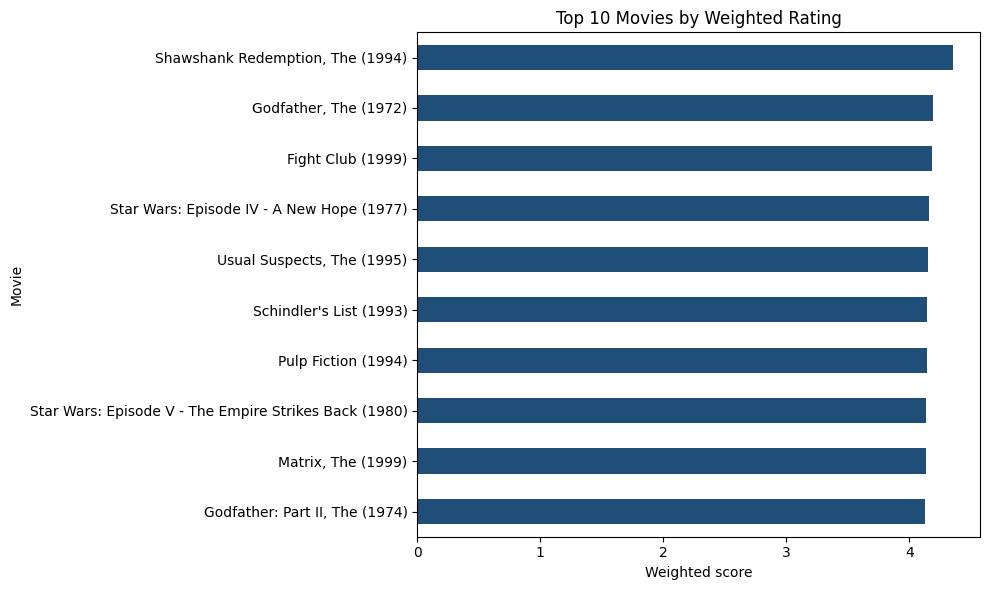

In [21]:
plot_data = weighted_recommendations.sort_values('weighted_score')

ax = plot_data.plot(
    x='title',
    y='weighted_score',
    kind='barh',
    figsize=(10, 6),
    color='#1F4E78',
    legend=False
)
ax.set_title('Top 10 Movies by Weighted Rating')
ax.set_xlabel('Weighted score')
ax.set_ylabel('Movie')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'top10_recommendations.png', dpi=150, bbox_inches='tight')
plt.show()

The bars are close together: the gap between rank 2 and rank 10 is only about 0.06 points, while *The Shawshank Redemption* stands clearly ahead. Small differences in the middle of the list should not be read as meaningful quality differences. The chart is saved as `images/top10_recommendations.png` for the README.

### 7.2 Basic tests

In [22]:
assert len(recommendations) <= 10
assert recommendations['movieId'].is_unique
assert recommendations['rating_count'].ge(50).all()
assert recommendations['average_rating'].between(0.5, 5.0).all()
assert recommendations['title'].notna().all()
assert len(weighted_recommendations) <= 10
assert weighted_recommendations['weighted_score'].notna().all()

# Additional structural checks
assert recommendations['average_rating'].is_monotonic_decreasing
assert weighted_recommendations['weighted_score'].is_monotonic_decreasing
assert weighted_recommendations['movieId'].is_unique
assert weighted_recommendations['weighted_score'].between(0.5, 5.0).all()
assert weighted_recommendations['rating_count'].ge(m).all()
assert (weighted_recommendations['weighted_score'] <= weighted_recommendations['average_rating']).all()

print('All checks passed.')

All checks passed.


The checks confirm structural expectations: no more than 10 unique movies, valid titles, ratings within 0.5–5.0, the minimum-count rule respected, and both lists correctly sorted. The final check confirms the weighted score never exceeds a movie's own average in this list, which is what shrinkage toward a lower overall mean should do for high-rated films. Passing tests does not show the list is *useful* to every visitor; human review of the output and its limitations is still needed.

### 7.3 Try different parameters

In [23]:
display(recommend_popular_movies(movie_stats, min_ratings=20, top_n=5))
display(recommend_popular_movies(movie_stats, min_ratings=100, top_n=5))
print('Eligible movies at threshold 20: ', (movie_stats['rating_count'] >= 20).sum())
print('Eligible movies at threshold 50: ', (movie_stats['rating_count'] >= 50).sum())
print('Eligible movies at threshold 100:', (movie_stats['rating_count'] >= 100).sum())

,movieId,title,genres,rating_count,average_rating
840,1104,"Streetcar Named Desire, A (1951)",Drama,20,4.475000
277,318,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
704,922,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),Drama|Film-Noir|Romance,27,4.333333
680,898,"Philadelphia Story, The (1940)",Comedy|Drama|Romance,29,4.310345
905,1204,Lawrence of Arabia (1962),Adventure|Drama|War,45,4.300000


,movieId,title,genres,rating_count,average_rating
277,318,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
659,858,"Godfather, The (1972)",Crime|Drama,192,4.289062
2224,2959,Fight Club (1999),Action|Crime|Drama|Thriller,218,4.272936
921,1221,"Godfather: Part II, The (1974)",Crime|Drama,129,4.259690
6298,48516,"Departed, The (2006)",Crime|Drama|Thriller,107,4.252336


Eligible movies at threshold 20:  1297
Eligible movies at threshold 50:  450
Eligible movies at threshold 100: 138


At a threshold of 20 the pool grows to **1,297** movies and the top of the list contains titles with only 20–45 ratings (for example *A Streetcar Named Desire* with 20 ratings, first with 4.475). At 100 the pool shrinks to **138** movies and every listed title has at least 107 ratings, all of them famous films. A low threshold admits more items but lets small samples move the rankings; a high threshold gives stable rankings but excludes lesser-known films that might be excellent.

### 7.4 Optional genre filter

In [24]:
def recommend_by_genre(stats, genre, min_ratings=30, top_n=10):
    mask = stats['genres'].str.contains(genre, case=False, na=False)
    return recommend_popular_movies(stats[mask], min_ratings, top_n)


display(recommend_by_genre(movie_stats, 'Comedy', 30, 10))

,movieId,title,genres,rating_count,average_rating
602,750,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,97,4.268041
898,1197,"Princess Bride, The (1987)",Action|Adventure|Comedy|Fantasy|Romance,142,4.232394
257,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,307,4.197068
3617,4973,"Amelie (Fabuleux destin d'Amélie Poulain, Le) ...",Comedy|Romance,120,4.183333
314,356,Forrest Gump (1994),Comedy|Drama|Romance|War,329,4.164134
862,1136,Monty Python and the Holy Grail (1975),Adventure|Comedy|Fantasy,136,4.161765
6659,57669,In Bruges (2008),Comedy|Crime|Drama|Thriller,41,4.158537
2992,4011,Snatch (2000),Comedy|Crime|Thriller,93,4.155914
1729,2324,Life Is Beautiful (La Vita è bella) (1997),Comedy|Drama|Romance|War,88,4.147727
520,608,Fargo (1996),Comedy|Crime|Drama|Thriller,181,4.116022


The comedy list surfaces different titles from the overall Top 10 (for example *Dr. Strangelove*, *The Princess Bride*, and *Amélie*). It is still non-personalized: everyone requesting "Comedy" gets the same result. It is a simple contextual filter, not a learned model of any individual's taste. The substring match on `genres` is also loose by design (it would treat `Comedy` inside any compound genre string as a match), which is acceptable for this teaching baseline.

## Part 8 — Interpret the results

### 8.1 Answers to the guiding questions (computed)

In [25]:
top_rated = movie_stats.sort_values(['rating_count', 'average_rating'], ascending=[False, False]).iloc[0]
print(f"Q1. Most-rated movie: {top_rated['title']} - {top_rated['rating_count']} ratings, "
      f"average {top_rated['average_rating']:.2f}")

first_threshold = recommendations.iloc[0]
print(f"Q2. First after the 50-rating threshold: {first_threshold['title']} "
      f"({first_threshold['average_rating']:.2f}, {first_threshold['rating_count']} ratings)")

first_weighted = weighted_recommendations.iloc[0]
print(f"Q3. First by weighted score: {first_weighted['title']} "
      f"(weighted {first_weighted['weighted_score']:.3f})")

print(f'Q4. Movies qualifying at the 90th percentile (m = {m:.0f}):', len(qualified))

for threshold in (20, 50, 100):
    print(f'Q5. Eligible movies at min_ratings={threshold}:', (movie_stats['rating_count'] >= threshold).sum())

counts_sorted = ratings_per_movie.sort_values(ascending=False)
top_decile = int(len(counts_sorted) * 0.10)
share = counts_sorted.head(top_decile).sum() / n_interactions
print(f'Q7. The {top_decile} most-rated movies (top 10%) account for {share:.1%} of all ratings')

unrated = len(movies) - n_movies_rated
print(f'Q8. Catalogue movies with no ratings at all: {unrated}')

Q1. Most-rated movie: Forrest Gump (1994) - 329 ratings, average 4.16
Q2. First after the 50-rating threshold: Shawshank Redemption, The (1994) (4.43, 317 ratings)
Q3. First by weighted score: Shawshank Redemption, The (1994) (weighted 4.356)
Q4. Movies qualifying at the 90th percentile (m = 27): 976
Q5. Eligible movies at min_ratings=20: 1297
Q5. Eligible movies at min_ratings=50: 450
Q5. Eligible movies at min_ratings=100: 138
Q7. The 972 most-rated movies (top 10%) account for 60.0% of all ratings
Q8. Catalogue movies with no ratings at all: 18


1. **Most ratings:** *Forrest Gump (1994)* with 329 ratings and an average of 4.16.
2. **First with the 50-rating threshold:** *The Shawshank Redemption (1994)*, average 4.43 from 317 ratings.
3. **First by weighted score:** also *The Shawshank Redemption*, with a weighted score of 4.356.
4. **Movies qualifying at the 90th percentile:** 976 (m = 27).
5. **Effect of a higher threshold:** the eligible pool shrinks (1,297 at 20 → 450 at 50 → 138 at 100), and the list moves toward heavily rated, famous films; the lowest rating count in the top 5 rises from 20 to 107.
6. **Why it is not personalized:** the ranking uses only aggregate statistics per movie. The user's identity, history, and tastes never enter the calculation, so every visitor receives an identical list.
7. **Possible bias:** *popularity bias*. The 972 most-rated movies (top 10%) hold 60.0% of all ratings. Recommending only already-popular films gives them more exposure and therefore more future ratings, while lesser-known films rarely reach the evidence bar and are never shown.
8. **A new movie with no ratings:** it has no average and no count, so both methods exclude it (the 18 unrated catalogue titles are already in this position). This is the cold-start problem. Options are to reserve some list slots for new titles, use content information such as genre or cast to estimate quality, or gather early feedback from a small audience.

### 8.2 Findings and Limitations

**Main dataset observations.** The ratings table contains 100,836 explicit ratings from 610 users on 9,724 movies; 18 of the 9,742 catalogue titles were never rated. Only about 1.7% of possible user–movie pairs are observed (98.30% sparsity). Ratings lean positive: 4.0 is the most common value, the mean is 3.50, and about 48% of ratings are 4.0 or higher. Attention is very uneven. The median movie has just 3 ratings, 3,446 movies have exactly one, and the most-rated title has 329. The most-rated 10% of movies receive 60% of all ratings.

**Difference between the ranking methods.** Ranking by rating count shows what is most visible, not what is best. Ranking by average alone is dominated by movies with one or two ratings that all average exactly 5.0. The minimum-50 method removes that noise with a hard cutoff, leaving 450 eligible movies, but it still trusts any average that clears the bar, so a movie with 57 ratings can outrank one with 300. The weighted score shrinks every movie's average toward the global mean of 3.50 in proportion to how little evidence it has. With m = 27 it considers 976 movies, yet no title in its Top 10 has fewer than 129 ratings. Only four titles are shared by the two lists, though *The Shawshank Redemption* is first in both. Rating count therefore does two jobs: it decides eligibility and it controls how much each average is trusted.

**Limitations.**
1. **Popularity bias.** Rewarding movies that already have many high ratings creates a feedback loop that hides good but little-known films.
2. **No personalization.** Every visitor gets the same list, regardless of taste, and the genre filter only narrows the audience, not the individual.
3. **Cold start.** New movies have no ratings and cannot appear until they gather them; the same is true of new users, for whom this baseline is the only fallback.
4. **Time.** The ratings span 1996 to 2018, and the data are a static snapshot. Popularity and taste change, so recent releases are underrepresented and old rankings may not describe today's audience.
5. **What a rating means.** A rating does not reveal why someone liked a film, and the users are MovieLens members who each rated at least 20 movies, so they are not a random sample of a general streaming audience.
6. **Policy choices.** The thresholds (50 ratings, the 90th percentile) are design decisions; the lists change when they change (section 6.5 and 7.3), and no evaluation against held-out data has been done to say which choice is better.

### 8.3 Recommended improvements

- Build a content-based model from genres or text features.
- Build collaborative filtering from user-rating patterns.
- Split the ratings into training and test sets and evaluate recommendation quality.
- Add diversity, novelty, and coverage measures rather than optimizing only rating score.
- Use time and recency, since preferences and popularity change.

## Reflection questions

1. **What did the popularity baseline do well?** It is simple, transparent, and cheap. It needs no user history, so it works for brand-new visitors, and the weighted version filters out low-evidence noise while producing a stable, defensible list of widely liked movies.
2. **Which users or movies might be disadvantaged?** Niche-taste users, whose preferred films rarely appear in a mass-appeal list, and new or little-known movies, which cannot collect the ratings needed to qualify (the 3,446 single-rating movies, for example).
3. **What additional data would be needed to personalize?** Per-user history (which we have) combined with enough overlap between users to find similar tastes, plus item features such as genre, cast, or plot text for content-based methods, and context such as time and device. For new users, some initial preference signals (e.g. a short onboarding choice of favourite genres).
4. **Which result would I use as the home-page baseline, and why?** The weighted-rating list. It admits more candidates than the hard cutoff (976 vs 450) while being more careful about small samples, and its threshold is derived from the data rather than fixed by hand. I would still add a small reserved space for newer titles to soften popularity bias.
5. **What will I change in the next version?** Split the data for evaluation, add a content-based model using genres, then a collaborative filter, and compare each with this baseline using accuracy plus diversity and coverage measures.

---
**Data attribution.** F. Maxwell Harper and Joseph A. Konstan. 2015. The MovieLens Datasets: History and Context. *ACM Transactions on Interactive Intelligent Systems* 5, 4, Article 19. <https://doi.org/10.1145/2827872>. Dataset: MovieLens latest-small, GroupLens Research, University of Minnesota (<https://grouplens.org/datasets/movielens/>).